<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Traffic_Sign_Detection_and_Classification_using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Traffic Sign Detection and Classification using Deep Learning

# Step 1: Problem Statement:

# Problem Statement

Traffic signs play a critical role in road safety and traffic management.
Drivers must quickly recognize and understand traffic signs while driving.

Manual monitoring of traffic signs is difficult in autonomous systems.
Therefore, there is a need for an automated system that can detect and
classify traffic signs accurately.

The goal of this project is to build a machine learning/deep learning
model that can identify traffic signs from image data using image
processing and Convolutional Neural Networks (CNN).

# Project Objective:


The primary objective of this project is to develop an intelligent
traffic sign classification system using deep learning techniques.

Objectives:

1. Load traffic sign image dataset
2. Perform image preprocessing
3. Normalize image data
4. Build a CNN-based classification model
5. Train the model on traffic sign images
6. Evaluate model performance
7. Predict traffic sign classes
8. Save the trained model for future use

The system should accurately classify traffic signs into
multiple categories.

# STEP 2  — Import Required Libraries

# Import Required Libraries

In this step, we import all the required Python libraries
needed for the Traffic Sign Detection project.

Libraries Used:

1. NumPy
   - Used for numerical operations and array handling.

2. Pandas
   - Used for data manipulation and analysis.

3. Matplotlib
   - Used for plotting graphs and displaying images.

4. OpenCV (cv2)
   - Used for image processing operations such as
     reading, resizing, and color conversion.

5. TensorFlow / Keras
   - Used for building and training the deep learning model.

6. Scikit-learn
   - Used for splitting the dataset into training
     and testing datasets.

This step prepares the environment for the complete project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

# STEP 2 — Mount Google Drive :    

# Mount Google Drive

The dataset is stored inside Google Drive.

Google Colab cannot directly access your Drive files,
so we mount Google Drive to connect Colab with Drive.

After mounting:
- We can read datasets
- Save trained models
- Store output files

This is necessary for handling large image datasets.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# STEP 3 — Define Dataset Path

# Define Dataset Path

The traffic sign dataset contains multiple folders.

Each folder represents a specific traffic sign class.

Example:

Train/
    0/
    1/
    2/
    ...

Where:
- Folder name = Class Label
- Images inside folder = Training Images

In this step, we define the dataset path
for loading images.

In [3]:
dataset_path = "/content/drive/MyDrive/trafsighnsdetc"

In [4]:
import os

# List all files and folders in the root of MyDrive
print("Contents of /content/drive/MyDrive/")
for item in os.listdir('/content/drive/MyDrive/'):
    print(item)


Contents of /content/drive/MyDrive/
Nalajam_Vennela_Resume.pdf
IMG-20230730-WA0006.jpg
21-3061 N.VENNELA-1.pdf
Nalajam_Vennela_AI&DS_resume-1.pdf
Colab Notebooks
vennela nalajam AWS cerificate.pdf
Nalajam vennela Resume.pdf
IMG-20260228-WA0002.jpg
Nalajam_Vennela_Resume_AIE.pdf
AIE_Datamites_NOC.pdf
Nalajam_Vennela_Resume_AIE.pdf1.pdf
Nalajam_Vennela_AI&DS_Intern_Resume.pdf
Nalajam_Vennela_AIDS_Resume.pdf
Recording 2026-05-03 193514.mp4
trafsighnsdetc


In [5]:
import os

# List all files and folders inside the dataset path
print(f"Contents of {dataset_path}/")
for item in os.listdir(dataset_path):
    print(item)


Contents of /content/drive/MyDrive/trafsighnsdetc/
Meta.csv
Test.csv
Train.csv
Test
Meta
Train


# STEP 4 — Load Dataset Images

# Load Dataset Images

In this step, we read all traffic sign images
from the dataset folders.

Process:
1. Read image from folder
2. Convert image color
3. Resize image
4. Store image in data list
5. Store label in labels list

Why resize images?
- Deep learning models require fixed image size.
- It reduces computational cost.

Why convert BGR to RGB?
- OpenCV loads images in BGR format.
- Matplotlib displays images in RGB format.

This step creates the dataset for model training.

In [10]:
import pandas as pd

train_csv = pd.read_csv(dataset_path + "/Train.csv")
test_csv = pd.read_csv(dataset_path + "/Test.csv")

print(train_csv.head())
print(test_csv.head())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      5

In [11]:
print("Training Data Shape:", train_csv.shape)
print("Testing Data Shape:", test_csv.shape)

print("Unique Classes:")
print(train_csv['ClassId'].unique())

print("Number of Classes:")
print(len(train_csv['ClassId'].unique()))

Training Data Shape: (39209, 8)
Testing Data Shape: (12630, 8)
Unique Classes:
[20  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Number of Classes:
43


# STEP 7 — Display Sample Images

# Visualize Sample Images

Before training the model, we visualize
sample traffic sign images.

Why visualization is important?
- Verify images loaded correctly
- Check labels
- Understand dataset visually
- Detect corrupted images

This helps avoid hidden dataset issues.

# STEP 8 — Split Dataset

# Split Dataset into Training and Testing

Machine learning models require:
- Training Data
- Testing Data

Training Data:
- Used to train the model

Testing Data:
- Used to evaluate model performance

Why split data?
- Prevent overfitting
- Evaluate real performance
- Test model generalization

We use:
- 80% Training Data
- 20% Testing Data

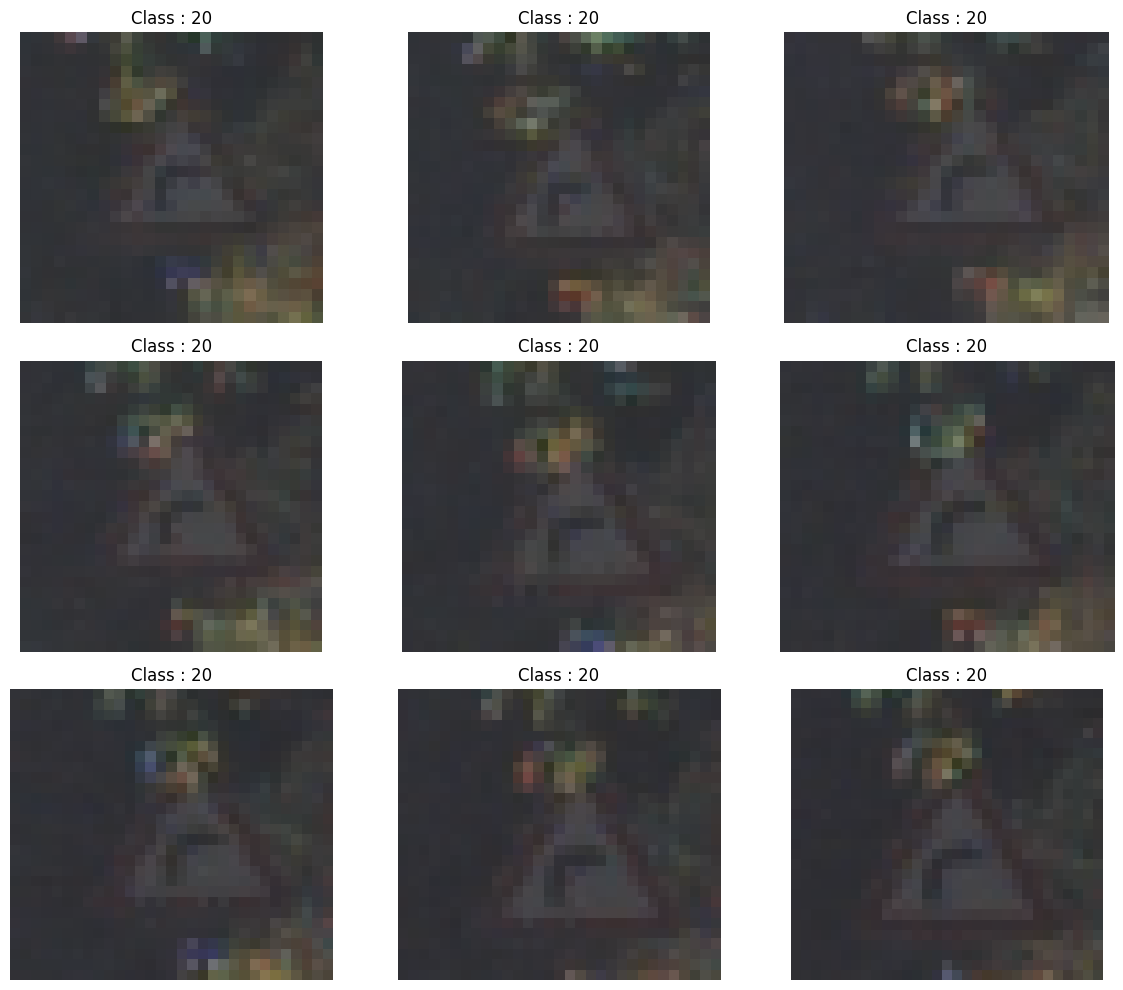

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))

for i in range(9):

    image_path = dataset_path + "/" + train_csv.iloc[i]['Path']

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title("Class : " + str(train_csv.iloc[i]['ClassId']))
    plt.axis('off')

plt.tight_layout()
plt.show()

# Step 9:  Image Preprocessing
Explanation

Deep learning models require images of equal size.

Steps Performed
Read image
Resize image
Convert image into array
Store labels

We resize all images to:

In [18]:
data = []
labels = []

for i in range(len(train_csv)):

    try:
        image_path = dataset_path + "/" + train_csv.iloc[i]['Path']

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (30,30))

        data.append(img)
        labels.append(train_csv.iloc[i]['ClassId'])

    except:
        print("Error loading image")

# Step 10: Convert into NumPy Arrays
Explanation

Neural networks work efficiently with NumPy arrays.

In [22]:
import numpy as np
data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

(39209, 30, 30, 3)
(39209,)


# Step 11: Normalize Image Data
Explanation

Normalization scales pixel values between 0 and 1.

This improves:

Training speed
Model accuracy
Convergence

In [23]:
data = data / 255.0

# Step 12: Convert Labels to One-Hot Encoding
Explanation

Deep learning classification models require categorical labels.

In [25]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(labels))

labels = to_categorical(labels, num_classes)

# Step 13: Split Dataset
Explanation

Dataset is divided into:

Training data
Validation data

Validation data helps evaluate model during training.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(31367, 30, 30, 3)
(7842, 30, 30, 3)


# Step 14: Build CNN Model
Explanation

CNN is highly effective for image classification.

Architecture Used
Convolution Layer
MaxPooling
Dropout
Fully Connected Dense Layers

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(30,30,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 15: Compile Model
Explanation

Compilation defines:

Optimizer
Loss Function
Performance Metric
Used
Optimizer → Adam
Loss → Categorical Crossentropy
Metric → Accuracy

In [31]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# STEP 16 — Display Model Summary

# Display Model Summary

Model summary shows:
- Total layers
- Output shapes
- Trainable parameters

This helps understand:
- Model architecture
- Complexity
- Number of parameters

It is useful for debugging and analysis.


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,627 (920.42 KB)

 Trainable params: 235,627 (920.42 KB)

 Non-trainable params: 0 (0.00 B)

# STEP 13 — Train CNN Model

# Train CNN Model

During training:
- Model learns traffic sign patterns
- Weights are updated
- Accuracy improves gradually

Important Parameters:

1. Epochs
   - Number of training cycles

2. Batch Size
   - Number of images processed together

3. Validation Data
   - Used to monitor model performance

Training is the learning phase of the neural network.

In [36]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.9958 - loss: 0.0169 - val_accuracy: 0.9941 - val_loss: 0.0311
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - accuracy: 0.9946 - loss: 0.0206 - val_accuracy: 0.9885 - val_loss: 0.1239
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9945 - loss: 0.0229 - val_accuracy: 0.9944 - val_loss: 0.0330
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.9970 - loss: 0.0115 - val_accuracy: 0.9945 - val_loss: 0.0303
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 53s 54ms/step - accuracy: 0.9952 - loss: 0.0187 - val_accuracy: 0.9936 - val_loss: 0.0418


# STEP 14 — Evaluate Model

# Evaluate Model Performance

After training, we test the model
using unseen test images.

Evaluation helps measure:
- Accuracy
- Loss
- Generalization capability

Higher accuracy indicates better performance.

In [37]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9936 - loss: 0.0418
Loss : 0.041814643889665604
Accuracy : 0.9936240911483765


# STEP 15 — Plot Accuracy Graph

# Plot Training and Validation Accuracy

Graphs help visualize:
- Learning progress
- Model performance
- Overfitting issues

Training Accuracy:
- Performance on training data

Validation Accuracy:
- Performance on unseen data

This step helps analyze model behavior.

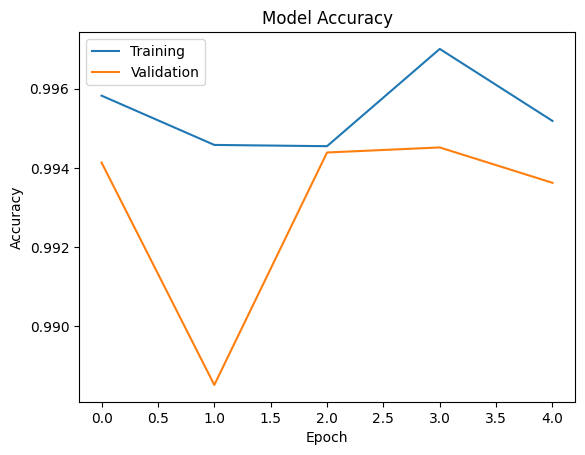

In [38]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

# STEP 16 — Plot Loss Graph

# Plot Loss Graph

Loss indicates prediction error.

Lower loss means:
- Better predictions
- Better learning

This graph helps detect:
- Underfitting
- Overfitting
- Training instability

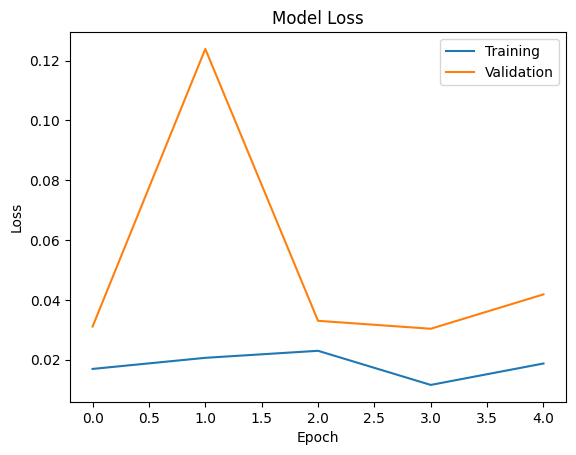

In [39]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

# STEP 19 — Predict New Traffic Sign

# Predict Traffic Sign

In this step, we test the model
using a new unseen traffic sign image.

Process:
1. Read image
2. Resize image
3. Normalize image
4. Predict class
5. Display result

This demonstrates real-world prediction.

In [41]:
import os

image_path = "/content/test.jpg"

# Try to load the image from the specified path
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}.")
    print("Please ensure 'test.jpg' is uploaded to the /content/ directory or provide a valid path.")
    print("For demonstration, using a sample image from the test dataset instead.")

    # Fallback: use an image path from the test_csv for demonstration
    sample_test_image_rel_path = test_csv.iloc[0]['Path'] # Example: 'Test/00000.png'
    image_path_from_dataset = os.path.join(dataset_path, sample_test_image_rel_path)
    print(f"Attempting to load: {image_path_from_dataset}")
    image = cv2.imread(image_path_from_dataset)

if image is not None:
    # Original image is BGR, convert to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize image to (30,30) to match model input (corrected from 32,32)
    image = cv2.resize(image, (30,30))

    # Normalize pixel values
    image = image / 255.0

    # Add batch dimension
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    predicted_class = np.argmax(prediction)

    print("Predicted Class :", predicted_class)
else:
    print("No image could be loaded for prediction. Please check file paths and availability.")

Error: Could not load image from /content/test.jpg.
Please ensure 'test.jpg' is uploaded to the /content/ directory or provide a valid path.
For demonstration, using a sample image from the test dataset instead.
Attempting to load: /content/drive/MyDrive/trafsighnsdetc/Test/00000.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted Class : 16


# STEP 20 — Display Predicted Image

# Display Predicted Traffic Sign

We display:
- Input image
- Predicted class

This helps visually verify prediction correctness.


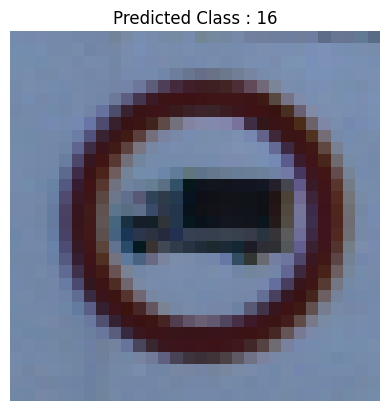

In [42]:
plt.imshow(image[0])

plt.title("Predicted Class : " + str(predicted_class))

plt.axis('off')

plt.show()

# STEP 21 — Traffic Sign Labels

# Define Traffic Sign Labels

Class numbers are difficult to understand.

We create label mappings to convert:
Class ID → Traffic Sign Name

This improves prediction readability.

In [43]:
classes = {
    0: 'Speed Limit 20 km/h',
    1: 'Speed Limit 30 km/h',
    2: 'Speed Limit 50 km/h',
    3: 'Speed Limit 60 km/h',
    4: 'Speed Limit 70 km/h',
    5: 'Speed Limit 80 km/h'
}

# STEP 22 — Final Prediction with Label

# Final Human-Readable Prediction

Instead of displaying only class number,
we display actual traffic sign name.

This improves user understanding.

In [47]:
import pandas as pd
import os

# Load Meta.csv to get all class labels
meta_csv_path = os.path.join(dataset_path, 'Meta.csv')
meta_df = pd.read_csv(meta_csv_path)

# Create a dictionary mapping ClassId to SignId (converted to string) as SignName is not available
# If you have a 'SignName' column, please use: classes = dict(zip(meta_df['ClassId'], meta_df['SignName']))
classes = dict(zip(meta_df['ClassId'], meta_df['SignId'].astype(str)))

print("Traffic Sign :", classes[predicted_class])

Traffic Sign : 3.3


# STEP 23 — Project Conclusion

# Project Conclusion

In this project, we successfully developed
a Traffic Sign Detection and Classification System
using Deep Learning.

Tasks Completed:
- Image preprocessing
- Dataset handling
- CNN model building
- Model training
- Evaluation
- Prediction

Technologies Used:
- Python
- TensorFlow
- Keras
- OpenCV
- NumPy
- Matplotlib

Outcome:
The CNN model can accurately classify
traffic sign images into multiple categories.

Applications:
- Autonomous vehicles
- Driver assistance systems
- Smart traffic monitoring
- Road safety systems